# Numbers-of-record audit: check every paper number against its source

This notebook is a runnable demo of the **evaluation artifact `gen_art_evaluation_8`** (iteration 5) from the research project
*"Occupancy is not integration: emerging scientific concepts in evolving knowledge networks"* (Applied Network Science).

The original `eval.py` is a **read-only, CPU-only, $0 audit**. It checks every number and verdict the paper may cite against
`iter_5/gen_strat/current_report.md` (the running research report). For each cited number it:

1. **freezes the audit universe** (every numeric token in the report plus the curated registry of cited numbers) *before* opening any source;
2. **re-reads or recomputes the intended source value** (`relpath::key`) and applies a frozen **match rule** (precision-aware rounding, p-value side-of-0.05 and Holm checks);
3. classifies each mismatch using **alternate sources** into `DRIFT_VALUE`, `WRONG_ESTIMATOR`, `WRONG_DEFINITION`, `NOT_TRACEABLE`, `MISSING_IN_REPORT`, and so on;
4. re-applies the frozen **decision rules** (verdicts), **verdict cells** and **text assertions**, and runs a **fold-label check**;
5. **auto-scans** every numeric token in the report against a per-artifact numeric index of the source files (≈3.7M values);
6. builds the **report-drift list** (what to change, the correct text and the source), graded by severity;
7. tests the detector itself by **seeded-error injection** (M5): it plants errors in a scratch copy and re-runs the detector blind;
8. compares against an **independent second code path** (M6).

**What is different in this demo.** The original reads ~40 files from 20 artifact workspaces on the research server. These cannot
ship to Colab, so `mini_demo_data.json` holds a snapshot built by running the *original* modules (`build_mini_demo_data.py`):
the audited report and hypothesis text, **100 of the 319 curated claims** (every known drift, every headline number and every non-OK flag, plus a
block-stratified fill), the value that each of their intended or alternate source specs returned, the tier-C recomputations, the decision-rule,
assertion and verdict-cell inputs, and a **slice of the numeric index** (every source value the auto-scan can hit for a report token or for any
single-digit variant of one). The audit code below is the original code. Only the few functions that opened files now read the snapshot,
and each of those changes is marked `# DEMO:`. The paper-table writer, Table-18 honesty check, review closure and case transcription (M7/M8/M10/M11)
need the raw artifact files, so this demo leaves them out.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT on Colab, always install
_pip('loguru==0.7.3')

# numpy, pandas, matplotlib — pre-installed on Colab, install locally only (Colab's exact versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'matplotlib==3.10.0')

In [2]:
# ---- original eval.py import block
from __future__ import annotations

import hashlib
import json
import math
import random
import re
import resource
import subprocess
import sys
import time
from collections import Counter, defaultdict
from datetime import datetime, timezone
from pathlib import Path

from loguru import logger

# ---- original audit_core.py imports
import csv
import os
from dataclasses import dataclass, field
from functools import lru_cache
from typing import Any

import numpy as np

# ---- added for the notebook (namespaces standing in for the audit_core / checks modules, results display, plots)
import builtins
import types
import pandas as pd
import matplotlib.pyplot as plt

WS = Path.cwd()  # DEMO: original WS = Path(__file__).resolve().parent (the artifact folder)
(WS / "logs").mkdir(exist_ok=True)
(WS / "results").mkdir(exist_ok=True)
(WS / "tables").mkdir(exist_ok=True)
logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
logger.add(str(WS / "logs" / "run.log"), rotation="30 MB", level="DEBUG");
# resource.setrlimit(resource.RLIMIT_AS, (24 * 1024 ** 3, 24 * 1024 ** 3))  # DEMO: the original's 24 GB cap is off (Colab free tier has ~12 GB)

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-8892b7-occupancy-is-not-integration-for-new/main/round-5/evaluation-8/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["description"])
print(f"report: {len(data['report_lines'])} lines | curated claims in demo: {len(data['claims'])} (full audit: 319) | "
      f"source specs snapshotted: {len(data['source_snapshot'])} | index slice: "
      f"{sum(sum(a['count']) for a in data['index_slice'].values()):,} of {sum(a['n_full'] for a in data['index_slice'].values()):,} indexed source values")

Curated subset for the numbers-of-record audit demo (gen_art_evaluation_8, iteration 5). report_lines/hypothesis_text are the audited texts; claims are 100 of the 319 curated registry claims; source_snapshot/tierc_snapshot/checks_* hold the source values the original audit read from ~40 artifact files; index_slice holds every indexed source value the auto-scan can hit.
report: 972 lines | curated claims in demo: 100 (full audit: 319) | source specs snapshotted: 103 | index slice: 1,385,834 of 3,760,007 indexed source values


## Configuration

All tunable parameters of the demo:

- `N_CLAIMS`: how many of the 100 curated claims in the demo data to audit, in registry order (D2 → MeSH → RQ1 → descriptive → adopter → data). The full audit has 319 claims.
- `N_PER_TYPE`: seeded errors planted per error type (digit change, CI-bound swap, estimator/fold relabel, verdict flip). The original uses **10** (40 errors).
- `RUN_FROZEN_SEED`: also re-run the injection on the pre-registered seed 20260929. The original does this; its result is reported as *not blind*, because that draw was inspected while the detector was being fixed.

The seeds (`SEED = 20260929`, `SEED_BLIND = 20260930`) are the original constants and are defined further down with the other `eval.py` constants.

In [5]:
N_CLAIMS = 100          # original: all 319 registry claims (the demo data carries 100)
N_PER_TYPE = 10        # original: 10 seeded errors per type
RUN_FROZEN_SEED = True  # original: True (second, non-blind injection run on seed 20260929)

## 1. `audit_core`: the frozen match rule

These are copied verbatim from `audit_core.py`: the artifact map, the flag taxonomy, the **frozen match rule**, and the parser that turns a
reported string such as `'1,544'`, `'−0.391'`, `'26%'` or `'< 0.001'` into a value with its shown precision.
`match_value` is the core of the audit:
- counts must be equal exactly;
- continuous values must agree within half a unit of the last shown decimal;
- p-values must also sit on the same side of 0.05, and of the Holm threshold when the claim carries one.

In [6]:
REPORT_REL = "3_invention_loop/iter_5/gen_strat/current_report.md"
HYPO_REL = "3_invention_loop/iter_4/upd_hypo/upd_hypo/.terminal_claude_agent_struct_out.json"


# artifact id -> workspace (run-root-relative). Taken from the report's own
# 'Source:' lines and [ARTIFACT:] markers, checked against the directory layout.
ARTIFACTS: dict[str, str] = {
    "art_94GEMUsgAmgK": "3_invention_loop/iter_1/gen_art/gen_art_dataset_1",
    "iter1_dataset_2": "3_invention_loop/iter_1/gen_art/gen_art_dataset_2",
    "art_HGiVAYhqO-6q": "3_invention_loop/iter_1/gen_art/gen_art_dataset_3",
    "art_QpM5SM6a7SH6": "3_invention_loop/iter_1/gen_art/gen_art_dataset_4",
    "art_bNCGUJX2MUhX": "3_invention_loop/iter_1/gen_art/gen_art_research_1",
    "art_eR1Z7fMlOcxs": "3_invention_loop/iter_2/gen_art/gen_art_dataset_5",
    "art_BdBvbNuNU8E7": "3_invention_loop/iter_2/gen_art/gen_art_experiment_1",
    "art_yjFB8Spw2w6M": "3_invention_loop/iter_2/gen_art/gen_art_experiment_2",
    "art_mbFjmo5rbbf8": "3_invention_loop/iter_2/gen_art/gen_art_experiment_3",
    "art_yWUkgWWKyq_h": "3_invention_loop/iter_2/gen_art/gen_art_experiment_4",
    "art__i2cIye01VnN": "3_invention_loop/iter_3/gen_art/gen_art_evaluation_1",
    "art_htO_gJuUn6Pr": "3_invention_loop/iter_3/gen_art/gen_art_experiment_5",
    "art_62TVG6A4f7Iy": "3_invention_loop/iter_3/gen_art/gen_art_experiment_6",
    "art_2Cd2JJypeGuA": "3_invention_loop/iter_3/gen_art/gen_art_experiment_7",
    "art_QKsLguxnGFQT": "3_invention_loop/iter_3/gen_art/gen_art_experiment_8",
    "art_WZ8fbLn79nCq": "3_invention_loop/iter_4/gen_art/gen_art_evaluation_2",
    "art_zw_JJGsUFSnd": "3_invention_loop/iter_4/gen_art/gen_art_evaluation_3",
    "art_mu0h0npvNX_u": "3_invention_loop/iter_4/gen_art/gen_art_evaluation_4",
    "art_FZ2OCJwV6xHs": "3_invention_loop/iter_4/gen_art/gen_art_evaluation_5",
    "art_XGdzjWgi-a88": "3_invention_loop/iter_4/gen_art/gen_art_experiment_9",
}


PATH_TO_ART = {v: k for k, v in ARTIFACTS.items()}


FLAGS = ["OK", "DRIFT_VALUE", "WRONG_ESTIMATOR", "WRONG_DEFINITION", "WRONG_FOLD",
         "NOT_TRACEABLE", "VERDICT_DRIFT", "MISSING_IN_REPORT"]


MATCH_RULE = {
    "counts_and_n_G": "exact equality after removing thousands separators",
    "continuous_and_ci_bounds": "|source - reported| <= 0.5 * 10^-d (+1e-9), d = decimals shown in the report; "
                                 "percentages compare source*100 at the shown decimals",
    "p_values": "equal after rounding the source to the reported significant figures (or 'p < x' holds), AND same side "
                "of 0.05, AND same side of the Holm threshold when one is attached to the claim",
    "verdicts": "the verdict string must equal the one the decision rule gives on the source numbers",
    "ci_structure": "a reported 'x [lo, hi]' must satisfy lo <= hi and lo <= x <= hi at the shown precision",
}


FLAG_DEFS = {
    "OK": "value/verdict matches its intended source under the match rule",
    "DRIFT_VALUE": "a source exists for the intended quantity but the reported value differs and matches no alternative",
    "WRONG_ESTIMATOR": "the number is real but comes from a different estimator/spec/model than the one the text names",
    "WRONG_DEFINITION": "the number or sentence is real but is given a wrong meaning (e.g. OR read as a risk ratio)",
    "WRONG_FOLD": "screen number labelled held-out (or the reverse), or MeSH/main mixed",
    "NOT_TRACEABLE": "no file contains the number; a replacement value is given or the number is dropped",
    "VERDICT_DRIFT": "the verdict stated differs from what the frozen decision rule gives on the source numbers",
    "MISSING_IN_REPORT": "a number of record (hypothesis evidence list / artifact output) that the report never states",
}


NUM_RE = re.compile(r"(?<![\w.\^])([−\-+]?)(\d[\d,]*(?:\.\d+)?|\.\d+)(?:\s?[×x]\s?10\^?([−\-]?\d+)|e([−\-]?\d+))?(%?)(?![\w])")


MINUS = str.maketrans({"−": "-", "–": "-", "‑": "-"})


@dataclass
class Reported:
    """A reported number as written, with its precision."""
    text: str
    value: float
    decimals: int
    sig: int
    is_pct: bool
    is_sci: bool
    lt: bool = False  # 'p < x'


def parse_reported(s: str) -> Reported | None:
    """Parse '1,544', '−0.391', '26%', '9.7e-5', '1e-5', '< 0.001', '1.4e-13'."""
    t = s.strip().translate(MINUS).replace(" ", "").replace(" ", "")
    lt = False
    if t.startswith("<"):
        lt, t = True, t[1:]
    if t.startswith("≤"):
        lt, t = True, t[1:]
    is_pct = t.endswith("%")
    t = t.rstrip("%")
    m = re.fullmatch(r"([+\-]?)(\d[\d,]*(?:\.\d+)?|\.\d+)(?:e([+\-]?\d+)|[×x]10\^?([+\-]?\d+))?", t)
    if not m:
        return None
    sign, mant, e1, e2 = m.groups()
    mant_clean = mant.replace(",", "")
    exp = e1 or e2
    val = float(mant_clean) * (10 ** int(exp) if exp else 1.0)
    if sign == "-":
        val = -val
    dec = len(mant_clean.split(".")[1]) if "." in mant_clean else 0
    digits = mant_clean.replace(".", "").lstrip("0")
    sig = max(1, len(digits))
    if exp:
        dec = dec - int(exp)
    return Reported(text=s.strip(), value=val, decimals=dec, sig=sig, is_pct=is_pct, is_sci=bool(exp), lt=lt)


def round_sig(x: float, sig: int) -> float:
    if x == 0 or not math.isfinite(x):
        return x
    return round(x, sig - int(math.floor(math.log10(abs(x)))) - 1)


def match_value(rep: Reported, src: float, kind: str = "cont", holm_threshold: float | None = None,
                sign_mode: str = "signed") -> bool:
    """Frozen match rule (see MATCH_RULE)."""
    if src is None or (isinstance(src, float) and not math.isfinite(src)):
        return False
    src = float(src)
    rv = rep.value
    if sign_mode == "abs":
        src, rv = abs(src), abs(rv)
    if kind == "count":
        return abs(src - rv) < 1e-9
    if kind == "pct":  # source is a fraction, report in percent
        src = src * 100.0
        return abs(src - rv) <= 0.5 * 10 ** (-rep.decimals) + 1e-9
    if kind == "p":
        if rep.lt:
            ok = src < rv + 1e-15
        elif rep.is_sci or rv < 0.001:
            ok = abs(round_sig(src, rep.sig) - rv) <= 1e-12 * max(1.0, abs(rv)) or \
                abs(src - rv) <= 0.5 * 10 ** (-rep.decimals) + 1e-15
        else:
            ok = abs(src - rv) <= 0.5 * 10 ** (-rep.decimals) + 1e-12 or abs(round_sig(src, rep.sig) - rv) < 1e-12
        same_side = (src < 0.05) == (rv < 0.05) or rep.lt
        if holm_threshold is not None:
            same_side = same_side and ((src < holm_threshold) == (rv < holm_threshold) or rep.lt)
        return ok and same_side
    # continuous
    return abs(src - rv) <= 0.5 * 10 ** (-rep.decimals) + 1e-9

## 2. Source access (served from the snapshot)

In the original, `read_source("relpath::key")` opens a JSON file and walks a `/`-separated key, or filters CSV rows with `csv:col=v|target`.
Specs that start with `recompute:` call a tier-C recomputation in `checks.RECOMPUTE` (Holm, IVW, counts, prevalences from row-level parquet/CSV files).
The demo replaces only the file access. Every spec returns the value that the original code produced for it. A spec whose read failed
raises the same exception type as before, so `evaluate_claim` classifies it the same way.

In [7]:
# DEMO: replaces audit_core.load_json / load_csv / get_by_key / read_source (file access) with the snapshot
SNAPSHOT = data["source_snapshot"]


def read_source(spec: str) -> Any:
    rec = SNAPSHOT.get(spec)
    if rec is None:
        raise KeyError(f"spec not in demo snapshot: {spec}")
    if "error_type" in rec:  # the original read raised this exception
        raise getattr(builtins, rec["error_type"])(rec["error"])
    return rec["value"]

## 3. Report parsing and the numeric index

This is the original tokenizer. It labels every number in the report as `num`, `year`, `ref`, `label` (e.g. *Table 16*, *R1*) or `hash`.
Only `num` tokens are audited.

For the auto-scan, the original `build_index` walks each artifact workspace and flattens every JSON, CSV and Markdown number into a sorted array.
That gives about 3.7M values in total, each with its `file::key` context. The demo rebuilds each `ArtifactIndex` from the snapshot slice instead.
A context is only ever used for its **file** (co-location) and its **fold words** (held-out / screen / MeSH), so the slice stores those two per
value. `ArtifactIndex` and `locate` are unchanged.

In [8]:
def read_report(path: Path | None = None) -> list[str]:
    return list(data["report_lines"])  # DEMO: original reads RUN_ROOT / REPORT_REL


@dataclass
class Token:
    line: int  # 1-based
    col: int
    text: str
    rep: Reported
    kind: str  # 'year', 'ref', 'num'
    section: str = ""


YEAR_OK = range(1985, 2031)


def tokenize_line(text: str, lineno: int) -> list[Token]:
    toks: list[Token] = []
    if re.match(r"^\[\d+\]\s", text):  # reference list entries
        return toks
    for m in NUM_RE.finditer(text):
        sign, mant, e_x, e_e, pct = m.groups()
        s = (sign or "") + mant + (f"e{(e_x or e_e)}" if (e_x or e_e) else "") + (pct or "")
        rep = parse_reported(s)
        if rep is None:
            continue
        start = m.start()
        before = text[max(0, start - 12):start]
        after = text[m.end():m.end() + 3]
        kind = "num"
        if re.search(r"\[$", before) and after.startswith("]") and "." not in mant and "," not in text[m.end():m.end() + 1]:
            kind = "ref"
        elif re.search(r"(Table|Artifact|Iteration|iteration|Figure|activity|Activity|F\d|M|m|R|E|S|G|W|k|C|D|H|Y)\s?$", before) and "." not in mant and not pct:
            # 'Table 16', 'Artifact 12', 'M3', 'R1', 'E4', 'G2', 'W2', 'Y3' identifiers
            kind = "label" if re.search(r"(Table|Artifact|Iteration|iteration|Figure|activity|Activity)\s$", before) or re.search(r"[A-Za-z]$", before) else "num"
        if kind == "num" and "." not in mant and "," not in mant and not pct and rep.value in YEAR_OK and not sign:
            kind = "year"
        if kind == "num" and re.search(r"(sha|SHA|hash|\.\.\.)", text[max(0, start - 30):m.end() + 6]) and re.search(r"[0-9a-f]{6,}", text[max(0, start - 10):m.end() + 10]):
            kind = "hash"
        toks.append(Token(line=lineno, col=start, text=s, rep=rep, kind=kind))
    return toks


def sections(lines: list[str]) -> list[tuple[int, int, str]]:
    """(start, end, heading) 1-based inclusive ranges for '#'/'##'/'###' headings."""
    heads = [(i + 1, l.strip("# ").strip()) for i, l in enumerate(lines) if l.startswith("#")]
    out = []
    for j, (s, h) in enumerate(heads):
        e = heads[j + 1][0] - 1 if j + 1 < len(heads) else len(lines)
        out.append((s, e, h))
    return out


def iteration_of_line(lines: list[str], lineno: int) -> int:
    it = 0
    for i in range(lineno):
        m = re.match(r"^# Iteration (\d)", lines[i])
        if m:
            it = int(m.group(1))
    return it

In [9]:
@dataclass
class ArtifactIndex:
    art: str
    values: np.ndarray
    contexts: list[str]
    order: np.ndarray = field(default=None)  # type: ignore
    n_files: int = 0

    def __post_init__(self):
        self.order = np.argsort(self.values)
        self.sorted = self.values[self.order]

    def candidates(self, lo: float, hi: float, limit: int = 400) -> list[int]:
        a = np.searchsorted(self.sorted, lo, side="left")
        b = np.searchsorted(self.sorted, hi, side="right")
        return [int(self.order[i]) for i in range(a, min(b, a + limit))]


def build_index(art: str, cap: int = 1_500_000) -> ArtifactIndex:
    # DEMO: original walks RUN_ROOT / ARTIFACTS[art] and flattens every JSON/CSV/MD number. Here the slice of that index
    # (value, file, fold-word mask, multiplicity) is expanded back into values + 'file::[fold words]' contexts.
    s = data["index_slice"][art]
    words = ("heldout", "screen", "mesh")
    ctx_of = {}
    ctx: list[str] = []
    for fi, mk, n in zip(s["file_id"], s["fold_mask"], s["count"]):
        key = (fi, mk)
        if key not in ctx_of:
            ctx_of[key] = f"{s['files'][fi]}::[{' '.join(w for b, w in enumerate(words) if mk >> b & 1)}]"
        ctx.extend([ctx_of[key]] * n)
    vals = np.repeat(np.array(s["value"], dtype=float), s["count"])
    return ArtifactIndex(art=art, values=vals, contexts=ctx, n_files=s["n_files"])


def locate(token: Reported, indexes: list[ArtifactIndex], cap: int = 50) -> list[str]:
    """Return contexts of source values matching a reported token under the match rule (no semantics)."""
    tol = 0.5 * 10 ** (-token.decimals) + 1e-9
    targets = [token.value]
    if token.is_pct:
        targets = [token.value / 100.0, token.value]
        tol_list = [0.5 * 10 ** (-(token.decimals + 2)) + 1e-12, tol]
    else:
        tol_list = [tol]
    hits: list[str] = []
    for ix in indexes:
        for t, tl in zip(targets, tol_list):
            for sign in ([1.0, -1.0] if t != 0 else [1.0]):
                tt = sign * t
                for i in ix.candidates(tt - tl, tt + tl, limit=cap):
                    hits.append(ix.contexts[i])
                    if len(hits) > cap:
                        return hits
    return hits


# DEMO: stands in for `import audit_core as AC`
AC = types.SimpleNamespace(
    REPORT_REL=REPORT_REL, HYPO_REL=HYPO_REL, ARTIFACTS=ARTIFACTS, PATH_TO_ART=PATH_TO_ART, FLAGS=FLAGS, MATCH_RULE=MATCH_RULE,
    FLAG_DEFS=FLAG_DEFS, NUM_RE=NUM_RE, MINUS=MINUS, Reported=Reported, parse_reported=parse_reported, round_sig=round_sig,
    match_value=match_value, read_source=read_source, read_report=read_report, Token=Token, tokenize_line=tokenize_line,
    sections=sections, iteration_of_line=iteration_of_line, ArtifactIndex=ArtifactIndex, build_index=build_index, locate=locate)

# quick look: the match rule on a few reported strings
for s_, v_, k_ in [("1.30", 1.300076888024346, "cont"), ("0.48", 0.8468, "p"), ("1,544", 1544.0, "count"), ("87%", 0.8705, "pct")]:
    print(f"reported {s_:>6} vs source {v_:<20} kind={k_:<5} -> match={AC.match_value(AC.parse_reported(s_), v_, k_)}")

reported   1.30 vs source 1.300076888024346    kind=cont  -> match=True
reported   0.48 vs source 0.8468               kind=p     -> match=False
reported  1,544 vs source 1544.0               kind=count -> match=True
reported    87% vs source 0.8705               kind=pct   -> match=True


## 4. `eval.py` constants: seeds, known-drift list and the claim registry

These are the original seeds, the known-drift list from the plan (the M4 gate requires all 12 to be detected), and the helpers.
`CLAIMS` normally comes from `registry.py`, which lists 319 claims, each with its intended source spec, its alternates, and a regex that locates
the reported value near a hint line in the report. Here the first `N_CLAIMS` of the demo's 100 are used.

In [10]:
SEED = 20260929


SEED_BLIND = 20260930  # fresh draw used for the reported (blind) M5 after the detector fix; see README


KNOWN_DRIFT = {  # the plan's known-drift list (gate: recall must be 100%)
    "K01_rq1_rescue_summary": "RQ1 rescue in the summary paragraph (line ~7)",
    "K02_learned_heading": "'What we have learned' heading rescues RQ1 (line ~867)",
    "K03_fig_methodology": "fig_methodology description (rescued R1, OR 3.14, placement)",
    "K04_26of27": "'26 of 27' robustness (lines ~486 note vs ~551)",
    "K05_primary_CT_p": "primary CT p 0.48 vs 0.85",
    "K06_83pct": "'83% single-paper'",
    "K08_table20": "Table 20's 1.14 / 1.09",
    "K09_or_31x": "'3.1x more likely'",
    "K10_neg_plac_matching": "NEG/PLAC/matching descriptions",
    "K11_k2_mesh": "'k = 2 replicates on ... MeSH'",
    "K12_mesh_leadlag": "'directionally consistent' MeSH lead-lag",
    "K14_establishment": "'host-native partners predict establishment' while EST_bin is null",
}


EXTRA_KNOWN = {"K13_constraint_mixed": "Table 20c constraint row mixes pooled-panel screen with event-study held-out (review item)"}


BLOCK_ORDER = ["D2", "MeSH", "RQ1", "descriptive", "adopter", "data"]


CLAIMS = data["claims"][:N_CLAIMS]  # DEMO: original `from registry import CLAIMS` (319 claims)


def sha(s: str | bytes) -> str:
    return hashlib.sha256(s if isinstance(s, bytes) else s.encode()).hexdigest()


def find_rep(lines: list[str], hint: int, regex: str) -> tuple[int, str] | None:
    """Locate a reported number by regex; the match nearest the hint line wins."""
    rx = re.compile(regex)
    best = None
    for i, l in enumerate(lines):
        m = rx.search(l)
        if m:
            d = abs(i + 1 - hint)
            if best is None or d < best[0]:
                best = (d, i + 1, m.group(1))
    return (best[1], best[2]) if best else None


def fmt(v) -> str:
    if v is None:
        return ""
    if isinstance(v, float):
        if v != 0 and (abs(v) < 1e-3 or abs(v) >= 1e6):
            return f"{v:.3e}"
        return f"{v:.6g}"
    return str(v)

## 5. Step 0: freeze the audit universe

`freeze` records every report token, every registry claim's located report value and every verdict word, then hashes them. This happens **before any
source value is read**, so the set of audited numbers cannot be adjusted after the sources are seen. The spec also records the match rule,
the flag taxonomy and the seeded-injection design.

In [11]:
def build_universe(lines: list[str], hypo_text: str) -> dict:
    toks = []
    for i, l in enumerate(lines):
        for t in AC.tokenize_line(l, i + 1):
            toks.append(dict(line=t.line, col=t.col, text=t.text, kind=t.kind))
    reg = []
    for c in CLAIMS:
        rv = find_rep(lines, c["rep"][0], c["rep"][1]) if c["rep"] else None
        hv = None
        if c.get("hyp"):
            m = re.search(c["hyp"], hypo_text)
            hv = m.group(1) if m else None
        reg.append(dict(id=c["id"], block=c["block"], report_line=rv[0] if rv else None, report_value=rv[1] if rv else None,
                        hyp_value=hv, src=c["src"], alt=[a[1] for a in c["alt"]]))
    verdict_words = [(i + 1, w) for i, l in enumerate(lines) for w in re.findall(
        r"\b(CONFIRMED|DEAD|GRAFTING|NEITHER|REPLICATED|NULL|MIXED|TRIGGERED|NOT MET|PASS|FAIL|SUPPORT|NOT SUPPORTED|R1_DEAD)\b", l)]
    return dict(tokens=toks, registry=reg, verdict_words=verdict_words)


def freeze(lines: list[str], hypo_text: str) -> dict:
    uni = build_universe(lines, hypo_text)
    uni_json = json.dumps(uni, sort_keys=True, ensure_ascii=False)
    spec = dict(
        artifact="gen_art_evaluation_8 (iteration 5, FIX slot): numbers-of-record audit",
        frozen_utc=datetime.now(timezone.utc).strftime("%Y-%m-%dT%H:%M:%SZ"),
        note="Frozen before any source file is opened: universe of cited numbers, match rule, flag taxonomy, known-drift list, "
             "seeded-injection design. Sources are only read after this file is written.",
        report=AC.REPORT_REL, report_sha256=sha("\n".join(lines)),  # DEMO: hash of the report text from the data
        hypothesis=AC.HYPO_REL, hypothesis_sha256=sha(hypo_text),  # DEMO: hash of the hypothesis text (original hashes the whole JSON file)
        universe_sha256=sha(uni_json), n_report_tokens=len(uni["tokens"]),
        n_report_tokens_by_kind=dict(Counter(t["kind"] for t in uni["tokens"])),
        n_registry_claims=len(uni["registry"]), n_verdict_words=len(uni["verdict_words"]),
        match_rule=AC.MATCH_RULE, flags=AC.FLAG_DEFS, known_drift=KNOWN_DRIFT, extra_known=EXTRA_KNOWN,
        severity_grades={"VERDICT-CHANGING": "the correct number/verdict changes a significance side, a CI-excludes-null statement or a decision-rule outcome",
                         "NUMBER-ONLY": "value differs but no conclusion changes", "WORDING": "definition/label/scope wording"},
        tiers={"R": "re-read from a summary JSON/CSV", "C": "recomputed from row-level files or from primitive quantities (Holm, IVW, counts, prevalences)"},
        seeded_injection=dict(seed=SEED, n_per_type=10, types=["digit_change", "ci_bound_swap", "estimator_fold_relabel", "verdict_flip"],
                              target_recall=0.95, blind="the detector receives only the perturbed text"),
        independent_rederivation=dict(n_sample=50, min_per_block=8, plus="all headline/verdict-bearing numbers", seed=SEED),
    )
    (WS / "results" / "audit_universe.json").write_text(uni_json)
    (WS / "results" / "audit_spec.json").write_text(json.dumps(spec, indent=2, ensure_ascii=False))
    spec["_audit_spec_sha256"] = sha((WS / "results" / "audit_spec.json").read_bytes())
    logger.info(f"FROZEN universe sha256 {spec['universe_sha256'][:16]} ({len(uni['tokens'])} tokens, {len(uni['registry'])} claims) at {spec['frozen_utc']}")
    return dict(spec=spec, universe=uni)

## 6. Step 1: evaluate each registry claim

`evaluate_claim` locates the reported value, reads the intended source and applies the match rule. If they disagree, it tries each
**alternate** spec (another estimator, fold or definition) and takes the first category that matches. A tier-C headline IRR must also match its
**recomputation** from primitives: `exp(b·SD(A_cont))` over the rebuilt estimation sample. In the demo, `tierc_irr` returns the value the original
recomputation produced from the row-level parquet files.

In [12]:
def source_value(spec: str):
    # DEMO: original `import checks` and, for "recompute:*" specs, `checks.RECOMPUTE[name]()` (row-level recomputation);
    # the snapshot holds the value the recomputation returned, keyed by the same spec
    return AC.read_source(spec)


TIERC_IRR = {  # headline IRR rows recomputed from primitives b, se and the row-level SD of A_cont
    "d2.scr.cop.irr": ("screen", "irr"), "d2.scr.cop.lo": ("screen", "lo"), "d2.scr.cop.hi": ("screen", "hi"),
    "d2.ho.cop.irr": ("heldout", "irr"), "d2.ho.cop.irr_sum": ("heldout", "irr"), "d2.ho.cop.lo": ("heldout", "lo"), "d2.ho.cop.hi": ("heldout", "hi"),
    "g4.R2.irr": ("mesh", "irr"), "g4.R2.irr_sum": ("mesh", "irr"), "g4.R2.lo": ("mesh", "lo"), "g4.R2.hi": ("mesh", "hi"),
}


# DEMO: original tierc_irr(which, part) reads d2_summary.json / heldout_robustness.csv / g4_models.json for b and se, loads the row-level
# event parquet, prunes FE groups (_prune) and returns exp(b * SD(A_cont)) and its CI; the snapshot holds its (value, description)
_TIERC = {tuple(TIERC_IRR[cid]): tuple(v) for cid, v in data["tierc_snapshot"].items()}


def tierc_irr(which: str, part: str) -> tuple[float, str]:
    if (which, part) not in _TIERC:
        raise KeyError(f"tier-C recompute ({which}, {part}) not in demo snapshot")
    return _TIERC[(which, part)]


def evaluate_claim(c: dict, lines: list[str], hypo_text: str) -> dict:
    out = dict(id=c["id"], block=c["block"], claim=c["claim"], fold_label=c["fold"], estimator=c["estimator"], artifact=c["art"],
               tier=c["tier"], headline=c["headline"], known=c.get("known") or "")
    rv = find_rep(lines, c["rep"][0], c["rep"][1]) if c["rep"] else None
    hv = None
    if c.get("hyp"):
        m = re.search(c["hyp"], hypo_text)
        hv = m.group(1) if m else None
    out.update(report_line=rv[0] if rv else "", report_value=rv[1] if rv else "", hyp_value=hv or "")
    out["source"] = c["src"] or ""
    sv, err = None, ""
    if c["src"]:
        try:
            sv = source_value(c["src"])
        except (KeyError, IndexError, FileNotFoundError, ValueError, TypeError, StopIteration) as e:
            err = f"{type(e).__name__}: {e}"
            logger.warning(f"source read failed for {c['id']}: {err}")
    out["source_value"] = sv if not isinstance(sv, str) else sv
    out["source_error"] = err
    out["recomputed"] = ""
    out["recompute_method"] = "recompute function (row-level / primitives)" if (c["src"] or "").startswith("recompute:") else "re-read"
    if c["id"] in TIERC_IRR:
        try:
            v, how = tierc_irr(*TIERC_IRR[c["id"]])
            out["recomputed"], out["recompute_method"] = v, how
        except (KeyError, FileNotFoundError, ValueError, TypeError) as e:
            out["recompute_method"] = f"tier-C recompute failed: {e}"
            out["tier"] = "R"
    compare_str = out["report_value"]
    rep = AC.parse_reported(compare_str) if compare_str else None
    kind = c["kind"]
    if rep is not None and rep.is_pct and kind == "cont":
        kind = "pct"
    if kind == "pctval":
        kind = "cont"

    def m(val) -> bool:
        return rep is not None and isinstance(val, (int, float)) and AC.match_value(rep, float(val), kind, c.get("holm"), c.get("sign", "signed"))

    flag, alt_used = None, ""
    if rep is None:
        flag = "MISSING_IN_REPORT"
        agrees = None
    elif c["src"] and not err and m(sv):
        flag = "OK"
    else:
        for cat, aspec in c["alt"]:
            try:
                av = source_value(aspec)
            except (KeyError, IndexError, FileNotFoundError, ValueError, TypeError) as e:
                logger.warning(f"alt read failed {c['id']}: {e}")
                continue
            if m(av):
                flag, alt_used = cat, f"{aspec} = {fmt(av)}"
                if cat == "OK":
                    out["source"], out["source_value"] = aspec, av
                break
        if flag is None:
            flag = "NOT_TRACEABLE" if (not c["src"] or err) else "DRIFT_VALUE"
    if c["tier"] == "C" and out["recomputed"] != "" and rep is not None and flag == "OK":
        if not m(out["recomputed"]):
            flag = "DRIFT_VALUE"
            alt_used = f"tier-C recompute disagrees: {fmt(out['recomputed'])}"
    # where the text is only in the hypothesis, still check the hypothesis value
    hyp_ok = ""
    if hv:
        hr = AC.parse_reported(hv)
        if hr is not None and sv is not None and isinstance(sv, (int, float)):
            hk = "pct" if (hr.is_pct and c["kind"] == "cont") else ("cont" if c["kind"] == "pctval" else c["kind"])
            hyp_ok = str(AC.match_value(hr, float(sv), hk, c.get("holm"), c.get("sign", "signed")))
    if flag == "MISSING_IN_REPORT" and not hv and c["src"]:
        out["note"] = "number of record (artifact output) never stated in the report"
    else:
        out["note"] = ""
    out.update(flag=flag, alt_match=alt_used, hyp_agrees=hyp_ok, replacement=c.get("replacement") or "",
               traced=bool((c["src"] and not err) or flag == "OK"))
    return out

## 7. Step 2: verdicts, verdict cells, fold labels and text assertions

- **Decision rules** (`checks.verdict_rules`): 13 rules from iterations 2–4, each with its verbatim text and the outcome recomputed from the audited
  numbers. The report's verdict statement must equal that outcome. For R1, the kill rule gives `R1_DEAD` and the report's rescue sentences are the drift lines.
- **Verdict cells**: every verdict column in the report's tables.
- **Fold check**: the fold word in the clause that carries an OK value (held-out, screen or MeSH) must match the claim's fold.
- **Text assertions**: known wrong sentences, for example "3.1× more likely" (an odds ratio read as a risk ratio) or "20 of 26 … excluding base row", paired with the correct text.

The inputs of `checks.*` were computed by the original `checks.py` from the source files and are loaded from the data.

In [13]:
# DEMO: stands in for `import checks` — the outputs of checks.verdict_rules() / assertions() / verdict_cells(), computed by the
# original checks.py from the source files (gen_strat rule texts, decision_rules.json, heldout_post.json, g4_summary.json, ...)
checks = types.SimpleNamespace(verdict_rules=lambda: data["checks_verdict_rules"], assertions=lambda: data["checks_assertions"],
                               verdict_cells=lambda: data["checks_verdict_cells"])


def evaluate_verdicts(lines: list[str]) -> list[dict]:
    # DEMO: `import checks` -> the checks namespace below
    rows = []
    for r in checks.verdict_rules():
        row = dict(iteration=r["it"], rule=r["rule"], rule_quote=r["quote"], rule_recorded=bool(r["quote"]) or r["outcome"] != "RULE_NOT_RECORDED",
                   outcome_from_rule=r["outcome"], inputs=r["inputs"], source=r["src"], report_line="", report_statement="")
        if r["outcome"] == "RULE_NOT_RECORDED":
            row.update(status="RULE_NOT_RECORDED", flag="RULE_NOT_RECORDED")
            rows.append(row)
            continue
        hit = find_rep(lines, r["report_hint"], r["report_regex"]) if r["report_regex"] else None
        expected = r.get("equiv", {}).get(r["outcome"], r["outcome"])
        if hit:
            row.update(report_line=hit[0], report_statement=hit[1])
            ok = hit[1].strip().lower() == str(expected).strip().lower()
        else:
            ok = False
            row.update(report_line=r["report_hint"], report_statement="verdict statement not found (changed or removed)")
        if r.get("rescue_lines"):
            # R1: the rule's outcome string must appear; the rescue sentences are the drift lines
            res = []
            for hint, rx in r["rescue_lines"]:
                h = find_rep(lines, hint, "(" + rx + ")")
                if h:
                    res.append(h[0])
            row["rescue_lines"] = res
            row["report_line"] = ";".join(str(x) for x in res) if not hit else hit[0]
            row["report_statement"] = "R1_DEAD / 'volume/churn correlates' never stated; persistent-neighbour row headlined" if not hit else hit[1]
        row.update(status="MATCH" if ok else "MISMATCH", flag="OK" if ok else "VERDICT_DRIFT")
        rows.append(row)
    return rows


def evaluate_vcells(lines: list[str]) -> list[dict]:
    # DEMO: `import checks` -> the checks namespace below
    out = []
    for v in checks.verdict_cells():
        hit = find_rep(lines, v["hint"], v["rx"])
        exp = str(v["expected"])
        if not hit:
            out.append(dict(id=v["id"], report_line=v["hint"], reported="(statement not found)", expected=exp, flag="VERDICT_DRIFT", source=v["src"]))
            continue
        rep = hit[1].strip()
        if v["mode"] == "passfail":
            ok = ("FAIL" in rep) == (exp == "FAIL") and (("PASS" in rep) == (exp == "PASS"))
        elif v["mode"] == "ci":
            ok = rep.lower() == exp.lower()
        else:
            ok = rep == exp
        out.append(dict(id=v["id"], report_line=hit[0], reported=rep, expected=exp, flag="OK" if ok else "VERDICT_DRIFT", source=v["src"]))
    return out


FOLD_OF_CLAIM = {"CONFIRMATORY": "heldout", "SCREEN": "screen", "MESH": "mesh"}


def clause_folds(line: str, value: str) -> set[str]:
    """fold words in the clause that carries the value: table row cells before it, or the sentence up to it."""
    pos = line.find(value)
    if pos < 0:
        return set()
    if line.lstrip().startswith("|"):
        return fold_label_of(line[:pos])
    m_after = re.match(r"\s*\(([^)]{0,25})\)", line[pos + len(value):])
    after = m_after.group(1) if m_after else ""
    if fold_label_of(after):
        return fold_label_of(after)
    before = line[:pos]
    cut = max(before.rfind(". "), before.rfind("; "), before.rfind(", "), before.rfind(" vs "), before.rfind("compared to"))
    return fold_label_of(before[cut + 1:])


def fold_check(claims: list[dict], lines: list[str]) -> list[dict]:
    out = []
    for c in claims:
        if not c["report_line"] or c["flag"] != "OK":
            continue
        want = FOLD_OF_CLAIM.get(c["fold_label"])
        if not want:
            continue
        got = clause_folds(lines[int(c["report_line"]) - 1], c["report_value"])
        if got and want not in got:
            out.append(dict(id=c["id"], report_line=c["report_line"], expected_fold=want, clause_folds=sorted(got), flag="WRONG_FOLD"))
    return out


def evaluate_assertions(lines: list[str]) -> list[dict]:
    # DEMO: `import checks` -> the checks namespace below
    out = []
    for a in checks.assertions():
        hit = find_rep(lines, a["hint"], "(" + a["pattern"] + ")")
        fired = hit is not None
        flag = a["flag"] if (fired and not a["supported"]) else "OK"
        out.append(dict(id=a["id"], report_line=hit[0] if hit else "", report_text=hit[1] if hit else "", statement_present=fired,
                        supported_by_source=a["supported"], flag=flag, correct_text=a["correct"], source=a["src"], known=a.get("known") or "",
                        severity=a.get("severity") or ""))
    return out

## 8. Step 3: auto-scan of every report token

Every `num` token in the report body is looked up in the numeric indexes of the artifacts that its section cites.
A token with at least one match under the match rule is `TRACED_AUTO`, otherwise `UNTRACED`. The scan also flags three things:
- `CI_INCONSISTENT`: an `x [lo, hi]` with `lo > hi` or `x` outside the interval;
- `FOLD_LABEL_CONFLICT`: the line names one fold, but every labelled hit comes from another fold;
- `NOT_COLOCATED`: the token's hit files share nothing with the files of its neighbouring tokens.

The match is only by value, so this is **weak evidence**. A changed digit often still matches some other source value by chance.

In [14]:
_INDEX: dict[str, AC.ArtifactIndex] = {}


def get_index(art: str) -> AC.ArtifactIndex:
    if art not in _INDEX:
        t0 = time.time()
        _INDEX[art] = AC.build_index(art)
        logger.debug(f"indexed {art}: {len(_INDEX[art].values)} values from {_INDEX[art].n_files} files in {time.time() - t0:.1f}s")
    return _INDEX[art]


ART_ITER = {a: int(re.search(r"iter_(\d)", p).group(1)) for a, p in AC.ARTIFACTS.items()}


FOLDER_TO_ART = {p.split("/")[-1] + f"@{ART_ITER[a]}": a for a, p in AC.ARTIFACTS.items()}


def line_artifacts(lines: list[str]) -> dict[int, list[str]]:
    secs = AC.sections(lines)
    out: dict[int, list[str]] = {}
    for s, e, h in secs:
        it = AC.iteration_of_line(lines, s)
        text = "\n".join(lines[s - 1:e])
        arts = set(re.findall(r"\[ARTIFACT:(art_[A-Za-z0-9_\-]+)\]", text)) & set(AC.ARTIFACTS)
        for fold in re.findall(r"(gen_art_[a-z]+_\d)", text):
            key = f"{fold}@{it}"
            if key in FOLDER_TO_ART:
                arts.add(FOLDER_TO_ART[key])
        for a in re.findall(r"\b(art_[A-Za-z0-9_\-]{12})", text):
            if a in AC.ARTIFACTS:
                arts.add(a)
        if not arts:
            arts = {a for a, i in ART_ITER.items() if (it == 0 or i <= it)}
        for ln in range(s, e + 1):
            out[ln] = sorted(arts)
    for ln in range(1, len(lines) + 1):
        out.setdefault(ln, sorted(AC.ARTIFACTS))
    return out


FOLD_WORDS = {"heldout": ("held-out", "held_out", "heldout"), "screen": ("screen",), "mesh": ("mesh",)}


def fold_label_of(line: str) -> set[str]:
    ll = line.lower()
    return {k for k, ws in FOLD_WORDS.items() if any(w in ll for w in ws)}


def ctx_folds(ctx: str) -> set[str]:
    cl = ctx.lower()
    return {k for k, ws in FOLD_WORDS.items() if any(w in cl for w in ws)}


CI_RX = re.compile(r"([−\-+]?\d[\d,]*\.?\d*)\s*%?\s*\[([−\-+]?\d[\d,]*\.?\d*)%?,\s*([−\-+]?\d[\d,]*\.?\d*)%?\]")


def _fkey(ctx: str) -> str:
    """file-level key of a hit context (the source file)."""
    return ctx.split("::", 1)[0]


def colocate(rows: list[dict], lines: list[str], window: int = 2) -> None:
    """A token is co-located if one of its hit files is also hit by >= 2 OTHER tokens within +-window lines of the same section.
    Tokens with no such consensus nearby are left unjudged; traced tokens whose files share nothing with the consensus are NOT_COLOCATED."""
    sec_of = {}
    for s0, e0, _ in AC.sections(lines):
        for ln in range(s0, e0 + 1):
            sec_of[ln] = s0
    toks = [r for r in rows if r["status"] == "TRACED_AUTO" and r["sig"] >= 2]
    by_line = defaultdict(list)
    for r in toks:
        by_line[r["line"]].append(r)
    for r in toks:
        cnt = Counter()
        for ln in range(r["line"] - window, r["line"] + window + 1):
            if sec_of.get(ln) != sec_of.get(r["line"]):
                continue
            for o in by_line.get(ln, []):
                if o is r:
                    continue
                for f in o["_files"]:
                    cnt[f] += 1
        consensus = {f for f, n in cnt.items() if n >= 2}
        if consensus and not (r["_files"] & consensus):
            r["status"] = "NOT_COLOCATED"


def autoscan(lines: list[str], line_arts: dict[int, list[str]]) -> list[dict]:
    rows = []
    for i, l in enumerate(lines):
        ln = i + 1
        if ln >= _ref_start(lines):
            break
        toks = [t for t in AC.tokenize_line(l, ln) if t.kind == "num"]
        if not toks:
            continue
        idx = [get_index(a) for a in line_arts.get(ln, [])]
        folds = fold_label_of(l)
        for t in toks:
            hits = AC.locate(t.rep, idx, cap=3000) if idx else []
            status = "TRACED_AUTO" if hits else "UNTRACED"
            if hits and len(folds) == 1 and "|" not in l[:2]:
                fl = next(iter(folds))
                hf = [ctx_folds(h) for h in hits]
                labelled = [f for f in hf if f]
                if labelled and len(labelled) == len(hf) and not any(fl in f for f in labelled):
                    status = "FOLD_LABEL_CONFLICT"
            rows.append(dict(line=ln, col=t.col, token=t.text, sig=t.rep.sig, status=status,
                             n_hits=len(hits), example_hit=hits[0] if hits else "", _files={_fkey(h) for h in hits}))
        for m in CI_RX.finditer(l.translate(AC.MINUS)):
            try:
                x, lo, hi = (float(g.replace(",", "")) for g in m.groups())
            except ValueError:
                continue
            p = AC.parse_reported(m.group(1).translate(AC.MINUS))
            tol = 0.5 * 10 ** (-(p.decimals if p else 2)) + 1e-9
            if lo > hi + tol or not (lo - tol <= x <= hi + tol):
                rows.append(dict(line=ln, col=m.start(), token=m.group(0), sig=0, status="CI_INCONSISTENT", n_hits=0, example_hit="", _files=set()))
    colocate(rows, lines)
    for r in rows:
        r.pop("_files", None)
    return rows


def _ref_start(lines: list[str]) -> int:
    for i, l in enumerate(lines):
        if l.strip() == "## References":
            return i + 1
    return len(lines) + 1

## 9. The detector and the report-drift list

`run_detector` runs everything above on a report text and returns the set of flagged lines with the reasons. It is used on the real report and,
blind, on each seeded copy. `drift_list` turns the flags into the rows of `report_drift.csv` (line, reported text, correct text, source).
`grade` assigns the severity: **VERDICT-CHANGING** when the fix changes a significance side, a CI-excludes-null statement or a rule outcome,
otherwise NUMBER-ONLY or WORDING.

In [15]:
def run_detector(lines: list[str], hypo_text: str, line_arts: dict[int, list[str]]) -> dict:
    claims = [evaluate_claim(c, lines, hypo_text) for c in CLAIMS]
    verdicts = evaluate_verdicts(lines)
    asserts = evaluate_assertions(lines)
    vcells = evaluate_vcells(lines)
    folds = fold_check(claims, lines)
    scan = autoscan(lines, line_arts)
    flagged: dict[int, set[str]] = defaultdict(set)
    for c in claims:
        if c["report_line"] and c["flag"] not in ("OK", "MISSING_IN_REPORT"):
            flagged[int(c["report_line"])].add(f"claim:{c['id']}:{c['flag']}")
    # a registry claim whose anchor vanished from the report is itself a detected change
    for c in claims:
        if c["flag"] == "MISSING_IN_REPORT" and CLAIM_BY_ID[c["id"]]["rep"] and not c["hyp_value"]:
            flagged[-1].add(f"anchor_lost:{c['id']}")
    for v in verdicts:
        if v["flag"] == "VERDICT_DRIFT":
            for ln in (v.get("rescue_lines") or ([v["report_line"]] if v["report_line"] else [])):
                flagged[int(ln)].add(f"verdict:{v['rule']}")
    for a in asserts:
        if a["flag"] != "OK" and a["report_line"]:
            flagged[int(a["report_line"])].add(f"assert:{a['id']}:{a['flag']}")
    for v in vcells:
        if v["flag"] != "OK":
            flagged[int(v["report_line"])].add(f"vcell:{v['id']}")
    for f in folds:
        flagged[int(f["report_line"])].add(f"fold:{f['id']}")
    for s in scan:
        if s["status"] in ("UNTRACED", "CI_INCONSISTENT", "FOLD_LABEL_CONFLICT", "NOT_COLOCATED") and (s["sig"] >= 2 or s["status"] != "UNTRACED"):
            flagged[s["line"]].add(f"scan:{s['status']}:{s['token']}")
    return dict(claims=claims, verdicts=verdicts, asserts=asserts, vcells=vcells, folds=folds, scan=scan, flagged=flagged)


CLAIM_BY_ID = {c["id"]: c for c in CLAIMS}


def p_side(v) -> bool | None:
    try:
        return float(v) < 0.05
    except (TypeError, ValueError):
        return None


def grade(c: dict) -> str:
    if c["flag"] in ("VERDICT_DRIFT",):
        return "VERDICT-CHANGING"
    if CLAIM_BY_ID[c["id"]]["kind"] == "p":
        r = AC.parse_reported(c["report_value"]) if c["report_value"] else None
        if r is not None and isinstance(c["source_value"], float) and (r.value < 0.05) != (c["source_value"] < 0.05):
            return "VERDICT-CHANGING"
    if c["flag"] == "WRONG_DEFINITION":
        return "WORDING" if not c["headline"] else "VERDICT-CHANGING"
    if c["headline"] and c["flag"] in ("NOT_TRACEABLE", "WRONG_ESTIMATOR", "DRIFT_VALUE", "WRONG_FOLD"):
        return "VERDICT-CHANGING" if c["id"].startswith(("rq1.persist.sum",)) else "NUMBER-ONLY"
    return "NUMBER-ONLY"


def drift_list(det: dict, lines: list[str]) -> list[dict]:
    rows = []
    for c in det["claims"]:
        if c["report_line"] and c["flag"] not in ("OK", "MISSING_IN_REPORT"):
            correct = c["replacement"] or (fmt(c["source_value"]) if c["source_value"] not in (None, "") else "remove (no source)")
            rows.append(dict(line=c["report_line"], report_text=lines[int(c["report_line"]) - 1].strip()[:300], reported=c["report_value"],
                             correct_text=correct, flag=c["flag"], severity=grade(c), source=c["source"] or c["alt_match"],
                             claim_id=c["id"], known=c["known"]))
    for v in det["verdicts"]:
        if v["flag"] == "VERDICT_DRIFT":
            for ln in v.get("rescue_lines") or [v["report_line"]]:
                if not ln:
                    continue
                rows.append(dict(line=ln, report_text=lines[int(ln) - 1].strip()[:300], reported=v["report_statement"],
                                 correct_text=f"{v['outcome_from_rule']} under the frozen rule: {v['inputs']}. RQ1 sentence: 'Structural precursors of sustained uptake are volume/churn correlates.'"
                                 if "R1" in v["rule"] else v["outcome_from_rule"],
                                 flag="VERDICT_DRIFT", severity="VERDICT-CHANGING", source=v["source"], claim_id="rule:" + v["rule"],
                                 known="K01_rq1_rescue_summary" if int(ln) < 20 else ("K02_learned_heading" if "R1" in v["rule"] else "")))
    for v in det.get("vcells", []):
        if v["flag"] != "OK":
            rows.append(dict(line=v["report_line"], report_text=lines[int(v["report_line"]) - 1].strip()[:300], reported=v["reported"], correct_text=v["expected"],
                             flag="VERDICT_DRIFT", severity="VERDICT-CHANGING", source=v["source"], claim_id=v["id"], known=""))
    for f in det.get("folds", []):
        rows.append(dict(line=f["report_line"], report_text=lines[int(f["report_line"]) - 1].strip()[:300], reported=",".join(f["clause_folds"]),
                         correct_text=f"fold label should be {f['expected_fold']}", flag="WRONG_FOLD", severity="NUMBER-ONLY", source="", claim_id=f["id"], known=""))
    for a in det["asserts"]:
        if a["flag"] != "OK":
            sev = a["severity"] or ("VERDICT-CHANGING" if a["flag"] == "VERDICT_DRIFT" else "WORDING")
            rows.append(dict(line=a["report_line"], report_text=lines[int(a["report_line"]) - 1].strip()[:300], reported=a["report_text"],
                             correct_text=a["correct_text"], flag=a["flag"], severity=sev, source=a["source"], claim_id=a["id"], known=a["known"]))
    rows.sort(key=lambda r: (int(r["line"]), r["claim_id"]))
    return rows

## 10. Seeded-error injection (M5): testing the detector itself

`perturb` plants `N_PER_TYPE` errors of each of four types. They go only on lines the clean detector did not already flag:
- a changed digit;
- swapped CI bounds;
- an estimator or fold relabel (held-out ↔ screen, co-primary → primary, …);
- a flipped verdict word.

`seeded_injection` re-runs the whole detector on the scratch copy, seeing only the perturbed text. It counts a planted error as detected when its line picks up a *new* flag reason.

In [16]:
LABEL_SWAPS = [("held-out", "screen"), ("Held-out", "Screen"), ("screen", "held-out"), ("Screen", "Held-out"),
               ("co-primary", "primary"), ("Co-primary", "Primary"), ("pooled panel", "event study"), ("pooled-panel", "event-study"),
               ("event study", "pooled panel"), ("MeSH", "main")]


VERDICT_SWAPS = [("CONFIRMED", "DEAD"), ("DEAD", "CONFIRMED"), ("GRAFTING", "NEITHER"), ("NEITHER", "GRAFTING"), ("REPLICATED", "NOT REPLICATED"),
                 ("NULL", "SUPPORTED"), ("MIXED", "BROKERAGE"), ("TRIGGERED", "NOT TRIGGERED"), ("NOT MET", "MET"), ("PASS", "FAIL"),
                 ("host-vocabulary", "artefact"), ("YES", "NO")]


def perturb(lines: list[str], clean_flagged: set[int], ref_start: int, rng: random.Random) -> list[dict]:
    num_lines = [i + 1 for i, l in enumerate(lines[:ref_start - 1]) if any(t.kind == "num" and t.rep.sig >= 2 for t in AC.tokenize_line(l, i + 1))]
    cands = [ln for ln in num_lines if ln not in clean_flagged and not lines[ln - 1].startswith("| ---")]
    ci_lines = [ln for ln in cands if CI_RX.search(lines[ln - 1].translate(AC.MINUS))]
    lab_lines = [ln for ln in cands if any(a in lines[ln - 1] for a, _ in LABEL_SWAPS)]
    ver_lines = [i + 1 for i, l in enumerate(lines[:ref_start - 1]) if (i + 1) not in clean_flagged and any(re.search(rf"\b{re.escape(a)}\b", l) for a, _ in VERDICT_SWAPS)]
    used: set[int] = set()
    perts = []

    def pick(pool):
        pool = [p for p in pool if p not in used]
        ln = rng.choice(pool)
        used.add(ln)
        return ln

    for _ in range(N_PER_TYPE):  # digit change  (DEMO: original range(10))
        ln = pick(cands)
        toks = [t for t in AC.tokenize_line(lines[ln - 1], ln) if t.kind == "num" and t.rep.sig >= 2]
        t = rng.choice(toks)
        digs = [k for k, ch in enumerate(t.text) if ch.isdigit()]
        k = rng.choice(digs[1:] if len(digs) > 1 else digs)
        new_d = str((int(t.text[k]) + rng.choice([1, 2, 3, 4, 5, 6, 7, 8, 9])) % 10)
        new_tok = t.text[:k] + new_d + t.text[k + 1:]
        l = lines[ln - 1]
        perts.append(dict(type="digit_change", line=ln, old=t.text, new=new_tok, text=l[:t.col] + l[t.col:].replace(t.text, new_tok, 1)))
    for _ in range(N_PER_TYPE):  # CI-bound swap  (DEMO: original range(10))
        ln = pick(ci_lines)
        l = lines[ln - 1]
        m = CI_RX.search(l.translate(AC.MINUS))
        s0, e0 = m.span()
        seg = l[s0:e0]
        mm = re.search(r"\[([^,\]]+),\s*([^\]]+)\]", seg)
        new_seg = seg[:mm.start()] + f"[{mm.group(2)}, {mm.group(1)}]" + seg[mm.end():]
        perts.append(dict(type="ci_bound_swap", line=ln, old=seg, new=new_seg, text=l[:s0] + new_seg + l[e0:]))
    for _ in range(N_PER_TYPE):  # estimator / fold relabel  (DEMO: original range(10))
        ln = pick(lab_lines)
        l = lines[ln - 1]
        opts = [(a, b) for a, b in LABEL_SWAPS if a in l]
        a, b = rng.choice(opts)
        perts.append(dict(type="estimator_fold_relabel", line=ln, old=a, new=b, text=l.replace(a, b, 1)))
    for _ in range(N_PER_TYPE):  # verdict flip  (DEMO: original range(10))
        ln = pick(ver_lines)
        l = lines[ln - 1]
        opts = [(a, b) for a, b in VERDICT_SWAPS if re.search(rf"\b{re.escape(a)}\b", l)]
        a, b = rng.choice(opts)
        perts.append(dict(type="verdict_flip", line=ln, old=a, new=b, text=re.sub(rf"\b{re.escape(a)}\b", b, l, count=1)))
    return perts


def seeded_injection(lines, hypo_text, line_arts, clean_det, seed: int = SEED, tag: str = "") -> dict:
    rng = random.Random(seed)
    clean_flag_lines = {ln for ln in clean_det["flagged"] if ln > 0}
    clean_reasons = {ln: set(v) for ln, v in clean_det["flagged"].items()}
    perts = perturb(lines, clean_flag_lines, _ref_start(lines), rng)
    scratch = list(lines)
    for p in perts:
        scratch[p["line"] - 1] = p["text"]
    (WS / "results" / f"seeded_report_scratch{tag}.md").write_text("\n".join(scratch))
    (WS / "results" / f"seeded_perturbations_SEALED{tag}.json").write_text(json.dumps(perts, indent=1, ensure_ascii=False))
    det = run_detector(scratch, hypo_text, line_arts)  # blind: sees only the perturbed text
    new_by_line = {ln: set(v) - clean_reasons.get(ln, set()) for ln, v in det["flagged"].items()}
    lost = det["flagged"].get(-1, set()) - clean_reasons.get(-1, set())
    lost_ids = {x.split(":", 1)[1] for x in lost}
    for p in perts:
        hit = bool(new_by_line.get(p["line"]))
        via_anchor = [cid for cid in lost_ids if CLAIM_BY_ID[cid]["rep"] and abs(CLAIM_BY_ID[cid]["rep"][0] - p["line"]) <= 3]
        p["detected"] = hit or bool(via_anchor)
        p["reasons"] = sorted(new_by_line.get(p["line"], set())) + [f"anchor_lost:{x}" for x in via_anchor]
    flagged_unpert = sorted(ln for ln, v in new_by_line.items() if v and ln > 0 and ln not in {p["line"] for p in perts})
    by_type = defaultdict(list)
    for p in perts:
        by_type[p["type"]].append(p["detected"])
    return dict(seed=seed, perturbations=perts, recall=sum(p["detected"] for p in perts) / len(perts),
                recall_by_type={k: sum(v) / len(v) for k, v in by_type.items()},
                new_flags_on_unperturbed_lines=flagged_unpert)

## 11. Independent re-derivation (M6)

`independent_sample` draws at least 8 claims per block (50 in total) plus every headline number. The original then runs
`rederive_independent.py` in a subprocess. That is a second code path that shares no code with the audit: plain `json` and `pandas` readers with its own
recomputations. The demo data holds the value that script returned for every eligible claim in the subset, and the comparison code is unchanged.

In [17]:
def independent_sample(claims: list[dict]) -> list[dict]:
    rng = random.Random(SEED)
    elig = [c for c in claims if c["source"] and c["source_value"] not in (None, "") and not c["source_error"]
            and isinstance(c["source_value"], (int, float))]
    by_block = defaultdict(list)
    for c in elig:
        by_block[c["block"]].append(c)
    pick: dict[str, dict] = {}
    for b, lst in by_block.items():
        for c in rng.sample(lst, min(8, len(lst))):
            pick[c["id"]] = c
    rest = [c for c in elig if c["id"] not in pick]
    rng.shuffle(rest)
    while len(pick) < 50 and rest:
        c = rest.pop()
        pick[c["id"]] = c
    for c in elig:  # all verdict-bearing / headline numbers
        if c["headline"]:
            pick[c["id"]] = c
    return [dict(id=c["id"], block=c["block"], src=c["source"], kind=CLAIM_BY_ID[c["id"]]["kind"], audit_value=c["source_value"],
                 report_value=c["report_value"], headline=c["headline"]) for c in pick.values()]


def run_independent(claims: list[dict]) -> dict:
    items = independent_sample(claims)
    sp = WS / "results" / "indep_sample.json"
    sp.write_text(json.dumps(items, indent=1, default=str))
    # DEMO: original runs `rederive_independent.py sample.json out.json` in a subprocess; its output for every eligible demo claim is in the data
    res = [dict(it, **data["independent_snapshot"].get(it["id"], dict(indep_value=None, indep_error="not in demo snapshot"))) for it in items]
    logger.info(f"rederive_independent.py (snapshot): re-derived {sum(r['indep_value'] is not None for r in res)}/{len(res)}")
    agree = 0
    for it in res:
        a, b = it["audit_value"], it.get("indep_value")
        ok = b is not None and (abs(float(a) - float(b)) <= 1e-9 * max(1.0, abs(float(a))))
        it["agree"] = bool(ok)
        agree += ok
    blocks = Counter(i["block"] for i in res)
    return dict(n=len(res), n_agree=agree, rate=agree / len(res) if res else float("nan"), per_block=dict(blocks),
                disagreements=[i for i in res if not i["agree"]], items=res)

## 12. Run the audit: freeze, index, detect, drift list

This is the body of `main()`, split into cells. The report and hypothesis come from the data. Then the universe is frozen, the 20 per-artifact
indexes are rebuilt from the slice, and the detector runs on the real report.

In [18]:
t0 = time.time()
lines = AC.read_report()
hypo_text = data["hypothesis_text"]  # DEMO: original reads the hypothesis JSON file
frz = freeze(lines, hypo_text)  # nothing from an artifact has been opened before this line
results: dict = dict(spec=frz["spec"])

line_arts = line_artifacts(lines)
logger.info("building per-artifact numeric indexes ...")
for a in sorted(AC.ARTIFACTS):
    get_index(a)
logger.info(f"indexes built for {len(_INDEX)} artifacts ({sum(len(i.values) for i in _INDEX.values())} values) in {time.time() - t0:.0f}s")

det = run_detector(lines, hypo_text, line_arts)
claims, verdicts, asserts, scan = det["claims"], det["verdicts"], det["asserts"], det["scan"]
det["drift"] = drift_list(det, lines)
logger.info(f"claims {Counter(c['flag'] for c in claims)}; verdict mismatches {sum(v['flag'] == 'VERDICT_DRIFT' for v in verdicts)}; "
            f"assertion flags {sum(a['flag'] != 'OK' for a in asserts)}; drift rows {len(det['drift'])}")

12:55:19|INFO   |FROZEN universe sha256 377e4dc21472cc5c (1534 tokens, 100 claims) at 2026-09-29T12:55:19Z


12:55:19|INFO   |building per-artifact numeric indexes ...


12:55:20|INFO   |indexes built for 20 artifacts (1385834 values) in 0s


12:55:21|INFO   |claims Counter({'OK': 66, 'DRIFT_VALUE': 13, 'MISSING_IN_REPORT': 8, 'WRONG_ESTIMATOR': 7, 'WRONG_DEFINITION': 4, 'NOT_TRACEABLE': 2}); verdict mismatches 1; assertion flags 17; drift rows 45


### Write the record of numbers, the drift list and the per-check outputs

These are written to `results/`, exactly as in the original.

In [19]:
import csv as _csv
rcols = ["id", "block", "claim", "fold_label", "estimator", "artifact", "source", "source_value", "recomputed", "recompute_method", "tier",
         "report_line", "report_value", "hyp_value", "hyp_agrees", "flag", "alt_match", "replacement", "headline", "known", "source_error", "note"]
with open(WS / "results" / "record_of_numbers_final.csv", "w", newline="") as fh:
    w = _csv.DictWriter(fh, fieldnames=rcols, extrasaction="ignore")
    w.writeheader()
    for c in claims:
        w.writerow({k: (fmt(c[k]) if isinstance(c.get(k), float) else c.get(k, "")) for k in rcols})
with open(WS / "results" / "report_drift.csv", "w", newline="") as fh:
    cols = ["line", "report_text", "reported", "correct_text", "flag", "severity", "source", "claim_id", "known"]
    w = _csv.DictWriter(fh, fieldnames=cols)
    w.writeheader()
    for r in det["drift"]:
        w.writerow(r)
(WS / "results" / "verdict_cells.json").write_text(json.dumps(det["vcells"], indent=1, ensure_ascii=False))
(WS / "results" / "fold_checks.json").write_text(json.dumps(det["folds"], indent=1, ensure_ascii=False))
(WS / "results" / "verdict_consistency.json").write_text(json.dumps(verdicts, indent=1, ensure_ascii=False))
(WS / "results" / "assertions.json").write_text(json.dumps(asserts, indent=1, ensure_ascii=False))
with open(WS / "results" / "autoscan_tokens.csv", "w", newline="") as fh:
    w = _csv.DictWriter(fh, fieldnames=["line", "col", "token", "sig", "status", "n_hits", "example_hit"])
    w.writeheader()
    for s in scan:
        w.writerow(s)

## 13. Metrics M1–M4

- **M1 traceability**: the share of curated claims with a readable source, and the share of report tokens the auto-scan traces.
- **M2 agreement**: OK rate among traced claims that the report states, split into tier R (re-read) and tier C (recomputed).
- **M3**: flag counts by block.
- **M4 known-drift gate**: every item on the known-drift list must show up in the drift list.

In [20]:
# ---------------- M1 / M2 / M3
blocks = BLOCK_ORDER
in_report = [c for c in claims if c["report_value"]]
m1 = {b: (sum(c["traced"] for c in claims if c["block"] == b) / max(1, sum(1 for c in claims if c["block"] == b))) for b in blocks}
m1_overall = sum(c["traced"] for c in claims) / len(claims)
toks = [s for s in scan if s["status"] in ("TRACED_AUTO", "UNTRACED", "FOLD_LABEL_CONFLICT")]
toks2 = [s for s in toks if s["sig"] >= 2]
toks3 = [s for s in toks if s["sig"] >= 3]
auto_rate = sum(s["status"] != "UNTRACED" for s in toks) / max(1, len(toks))
auto_rate2 = sum(s["status"] != "UNTRACED" for s in toks2) / max(1, len(toks2))
auto_rate3 = sum(s["status"] != "UNTRACED" for s in toks3) / max(1, len(toks3))
by_iter = defaultdict(lambda: [0, 0])
for s in toks2:
    it = AC.iteration_of_line(lines, s["line"])
    by_iter[it][0] += s["status"] != "UNTRACED"
    by_iter[it][1] += 1
traced_rep = [c for c in in_report if c["traced"]]
tierR = [c for c in traced_rep if c["tier"] == "R"]
tierC = [c for c in traced_rep if c["tier"] == "C"]
m2 = dict(overall=sum(c["flag"] == "OK" for c in traced_rep) / max(1, len(traced_rep)),
          tier_R=sum(c["flag"] == "OK" for c in tierR) / max(1, len(tierR)), n_R=len(tierR),
          tier_C=sum(c["flag"] == "OK" for c in tierC) / max(1, len(tierC)), n_C=len(tierC))
head = [c for c in claims if c["headline"]]
m2["headline_n"] = len(head)
m2["headline_tier_C"] = sum(c["tier"] == "C" for c in head)
m2["headline_not_tier_C"] = [c["id"] for c in head if c["tier"] != "C"]
flag_tab = defaultdict(Counter)
for c in claims:
    flag_tab[c["block"]][c["flag"]] += 1
for a in asserts:
    if a["flag"] != "OK":
        flag_tab["text-assertions"][a["flag"]] += 1
for v in verdicts:
    flag_tab["verdicts"][v["flag"]] += 1
with open(WS / "results" / "flags_by_block.csv", "w", newline="") as fh:
    allf = AC.FLAGS + ["RULE_NOT_RECORDED"]
    w = _csv.writer(fh)
    w.writerow(["block"] + allf + ["total"])
    for b, cnt in flag_tab.items():
        w.writerow([b] + [cnt.get(f, 0) for f in allf] + [sum(cnt.values())])

# ---------------- M4 known-drift gate
detected_known = {r["known"] for r in det["drift"] if r["known"]}
known_rows = [dict(id=k, desc=v, detected=k in detected_known,
                   lines=sorted({int(r["line"]) for r in det["drift"] if r["known"] == k})) for k, v in {**KNOWN_DRIFT, **EXTRA_KNOWN}.items()]
gate_known = [r for r in known_rows if r["id"] in KNOWN_DRIFT]
m4_recall = sum(r["detected"] for r in gate_known) / len(gate_known)
sev = Counter(r["severity"] for r in det["drift"])
drift_lines = sorted({int(r["line"]) for r in det["drift"]})
logger.info(f"M4 known-drift recall {m4_recall:.2f}; missing {[r['id'] for r in gate_known if not r['detected']]}")

12:55:21|INFO   |M4 known-drift recall 1.00; missing []


## 14. M5 seeded injection and precision

This runs the injection on the blind seed (20260930). If `RUN_FROZEN_SEED` is set, it also runs the pre-registered seed (20260929), which is not blind.
Precision comes from the original manual labels of 30 flagged lines, and only the lines that fall in this run's sample are counted.

In [21]:
# ---------------- M5 seeded injection
logger.info("seeded-error injection (blind re-run on a scratch copy) ...")
inj0 = seeded_injection(lines, hypo_text, line_arts, det, seed=SEED, tag="_seed20260929") if RUN_FROZEN_SEED else dict(recall=float("nan"), recall_by_type={})  # DEMO: optional
inj = seeded_injection(lines, hypo_text, line_arts, det, seed=SEED_BLIND, tag="_seed20260930")
inj["frozen_seed_run"] = dict(seed=SEED, recall=inj0["recall"], recall_by_type=inj0["recall_by_type"],
                              note="the executor inspected this draw after a first detector version (recall 0.35) and then fixed the detector "
                                   "generically; this re-run is therefore NOT blind")
logger.info(f"M5 recall blind seed {SEED_BLIND}: {inj['recall']:.3f} {inj['recall_by_type']}; frozen seed {SEED}: {inj0['recall']:.3f}")
clean_flagged = sorted(ln for ln in det["flagged"] if ln > 0)
rng = random.Random(SEED + 1)
fp_sample = rng.sample(clean_flagged, min(30, len(clean_flagged)))
fp_rows = [dict(line=ln, text=lines[ln - 1][:240], reasons=sorted(det["flagged"][ln])) for ln in sorted(fp_sample)]
(WS / "results" / "precision_check_sample.json").write_text(json.dumps(fp_rows, indent=1, ensure_ascii=False))
m5_precision = None
if True:  # DEMO: original reads results/precision_manual_labels.json if it exists; the labels are in the data
    lab = data["precision_manual_labels"]
    lab = {int(k): v for k, v in lab.items()}
    judged = [lab[r["line"]] for r in fp_rows if r["line"] in lab]
    if judged:
        m5_precision = sum(1 for j in judged if j.startswith("TRUE")) / len(judged)
inj["precision_manual"] = m5_precision
inj["n_flagged_clean_lines"] = len(clean_flagged)
(WS / "results" / "seeded_injection.json").write_text(json.dumps(inj, indent=1, ensure_ascii=False, default=str));

12:55:21|INFO   |seeded-error injection (blind re-run on a scratch copy) ...


12:55:24|INFO   |M5 recall blind seed 20260930: 0.600 {'digit_change': 0.4, 'ci_bound_swap': 1.0, 'estimator_fold_relabel': 0.1, 'verdict_flip': 0.9}; frozen seed 20260929: 0.550


## 15. M6 independent re-derivation and M9 decision-rule consistency

In [22]:
# ---------------- M6 independent re-derivation
ind = run_independent(claims)
(WS / "results" / "independent_rederivation.json").write_text(json.dumps(ind, indent=1, default=str))
logger.info(f"M6 independent agreement {ind['n_agree']}/{ind['n']}")

# DEMO: M11 (Table-18 honesty), paper tables + M7 assertions, M8 review closure, cases.md and M10 need the raw artifact files -> not run
m9_mis = [v for v in verdicts if v["flag"] == "VERDICT_DRIFT"]

12:55:24|INFO   |rederive_independent.py (snapshot): re-derived 63/63


12:55:24|INFO   |M6 independent agreement 63/63


## 16. Aggregate metrics (`metrics_agg`, as in `eval_out.json`)

This is the original `metrics` dict without the M7, M8, M10 and M11 entries. The cell also writes a demo `eval_out.json` in the `exp_eval_sol_out` format, holding the
record-of-numbers, report-drift, verdict-consistency, seeded-injection and independent-rederivation datasets.

In [23]:
ex_claims = []
for c in claims:
    ex_claims.append(dict(
        input=f"[{c['id']}] {c['claim']} | fold {c['fold_label']} | estimator {c['estimator']} | report line {c['report_line']}: '{c['report_value']}'"
              + (f" | hypothesis: '{c['hyp_value']}'" if c["hyp_value"] else ""),
        output=f"source {c['source']} = {fmt(c['source_value'])}" + (f"; tier-C recompute {fmt(c['recomputed'])}" if c['recomputed'] != "" else "")
               + (f"; replacement: {c['replacement']}" if c["replacement"] and c["flag"] != "OK" else ""),
        predict_report=str(c["report_value"] or c["hyp_value"] or ""), predict_source=fmt(c["source_value"]),
        predict_flag=c["flag"],
        metadata_block=c["block"], metadata_fold=c["fold_label"], metadata_tier=c["tier"], metadata_artifact=c["artifact"],
        metadata_headline=bool(c["headline"]), metadata_known_drift=c["known"],
        eval_traced=float(bool(c["traced"])), eval_in_report=float(bool(c["report_value"])),
        eval_ok=float(c["flag"] == "OK"), eval_flag_nonok=float(c["flag"] not in ("OK", "MISSING_IN_REPORT"))))
ex_drift = [dict(input=f"line {r['line']}: {r['report_text']}", output=r["correct_text"][:600], predict_flag=r["flag"], predict_severity=r["severity"],
                 metadata_source=r["source"], metadata_claim_id=r["claim_id"], metadata_known=r["known"],
                 eval_verdict_changing=float(r["severity"] == "VERDICT-CHANGING")) for r in det["drift"]]
ex_inj = [dict(input=f"{p['type']} at line {p['line']}: '{p['old']}' -> '{p['new']}'", output="detected" if p["detected"] else "missed",
               predict_detector="; ".join(p["reasons"])[:500], metadata_type=p["type"], eval_detected=float(p["detected"])) for p in inj["perturbations"]]
ex_ind = [dict(input=f"[{i['id']}] {i['src']}", output=fmt(i.get("indep_value")), predict_audit=fmt(i["audit_value"]),
               predict_independent=fmt(i.get("indep_value")), metadata_block=i["block"], eval_agree=float(i["agree"])) for i in ind["items"]]
ex_ver = [dict(input=f"iteration {v['iteration']} rule: {v['rule']}", output=v["outcome_from_rule"], predict_report=str(v["report_statement"]),
               predict_status=v["status"], metadata_quote=v["rule_quote"][:300], metadata_inputs=v["inputs"],
               eval_match=float(v["status"] == "MATCH")) for v in verdicts]
ex_tab = []  # DEMO: no paper tables / table assertions in the demo
metrics = dict(
    M1_traceability_curated=m1_overall, M1_traceability_autoscan_all_tokens=auto_rate, M1_traceability_autoscan_sig2=auto_rate2,
    M1_traceability_autoscan_sig3=auto_rate3,
    **{f"M1_traceability_{b}": v for b, v in m1.items()},
    M2_agreement_overall=m2["overall"], M2_agreement_tier_R=m2["tier_R"], M2_agreement_tier_C=m2["tier_C"],
    M2_headline_share_tier_C=m2["headline_tier_C"] / max(1, m2["headline_n"]),
    M3_n_nonOK_numbers=float(sum(c["flag"] not in ("OK", "MISSING_IN_REPORT") for c in claims)),
    M3_n_missing_in_report=float(sum(c["flag"] == "MISSING_IN_REPORT" for c in claims)),
    M3_n_wrong_estimator=float(sum(c["flag"] == "WRONG_ESTIMATOR" for c in claims)),
    M3_n_wrong_definition=float(sum(c["flag"] == "WRONG_DEFINITION" for c in claims) + sum(a["flag"] == "WRONG_DEFINITION" for a in asserts)),
    M3_n_drift_value=float(sum(c["flag"] == "DRIFT_VALUE" for c in claims)),
    M3_n_not_traceable=float(sum(c["flag"] == "NOT_TRACEABLE" for c in claims)),
    M4_report_drift_lines=float(len(drift_lines)), M4_verdict_changing=float(sev.get("VERDICT-CHANGING", 0)),
    M4_number_only=float(sev.get("NUMBER-ONLY", 0)), M4_wording=float(sev.get("WORDING", 0)), M4_known_drift_recall=m4_recall,
    M5_seeded_recall=inj["recall"], **{f"M5_recall_{k}": v for k, v in inj["recall_by_type"].items()},
    M5_seeded_recall_frozen_seed_not_blind=inj["frozen_seed_run"]["recall"],
    M6_independent_agreement=ind["rate"], M6_n_rederived=float(ind["n"]),
    M9_rule_mismatches=float(len(m9_mis)), M9_rules_evaluated=float(len(verdicts)),  # DEMO: M7/M8/M10/M11 not run
)
if m5_precision is not None:
    metrics["M5_precision_manual30"] = m5_precision
out = dict(metadata=dict(evaluation_name="numbers-of-record audit (iteration 5 FIX slot) - DEMO subset", audit_spec_sha256=frz["spec"]["_audit_spec_sha256"],
                         universe_sha256=frz["spec"]["universe_sha256"], frozen_utc=frz["spec"]["frozen_utc"], report=AC.REPORT_REL,
                         summary_file="results/audit_summary.json"),
           metrics_agg={k: float(v) for k, v in metrics.items()},
           datasets=[dict(dataset="record_of_numbers", examples=ex_claims), dict(dataset="report_drift", examples=ex_drift or [dict(input="none", output="none")]),
                     dict(dataset="verdict_consistency", examples=ex_ver), dict(dataset="seeded_injection", examples=ex_inj),
                     dict(dataset="independent_rederivation", examples=ex_ind)])  # DEMO: no table_assertions dataset
(WS / "eval_out.json").write_text(json.dumps(out, indent=1, ensure_ascii=False, default=str))
logger.info(f"done in {time.time() - t0:.0f}s; metrics: " + json.dumps({k: round(v, 3) for k, v in out['metrics_agg'].items()}))

12:55:24|INFO   |done in 4s; metrics: {"M1_traceability_curated": 0.98, "M1_traceability_autoscan_all_tokens": 0.993, "M1_traceability_autoscan_sig2": 0.993, "M1_traceability_autoscan_sig3": 0.988, "M1_traceability_D2": 0.938, "M1_traceability_MeSH": 1.0, "M1_traceability_RQ1": 1.0, "M1_traceability_descriptive": 1.0, "M1_traceability_adopter": 1.0, "M1_traceability_data": 1.0, "M2_agreement_overall": 0.733, "M2_agreement_tier_R": 0.741, "M2_agreement_tier_C": 0.719, "M2_headline_share_tier_C": 0.75, "M3_n_nonOK_numbers": 26.0, "M3_n_missing_in_report": 8.0, "M3_n_wrong_estimator": 7.0, "M3_n_wrong_definition": 17.0, "M3_n_drift_value": 13.0, "M3_n_not_traceable": 2.0, "M4_report_drift_lines": 32.0, "M4_verdict_changing": 6.0, "M4_number_only": 23.0, "M4_wording": 16.0, "M4_known_drift_recall": 1.0, "M5_seeded_recall": 0.6, "M5_recall_digit_change": 0.4, "M5_recall_ci_bound_swap": 1.0, "M5_recall_estimator_fold_relabel": 0.1, "M5_recall_verdict_flip": 0.9, "M5_seeded_recall_frozen_seed

## 17. Results: demo run vs the full audit

The table compares each demo metric with the full-run value from `full_eval_out.json` (319 claims, 40 seeded errors).
- **Auto-scan traceability** (M1 autoscan) covers every token of the report, so it reproduces the full run exactly. This also checks that the index slice is faithful.
- At the default config (`N_CLAIMS = 100`, `N_PER_TYPE = 10`), the demo subset contains every flagged claim. The following should therefore equal the full audit:
  - the non-OK flag counts (M3);
  - the drift list: 45 rows on 32 lines, 6 of them verdict-changing (M4), with the known-drift gate at 12/12;
  - the blind-seed injection recall: 0.60 overall, 0.4 / 1.0 / 0.1 / 0.9 by type (M5).
- Agreement (M2) comes out **lower than in the full audit by design**, because the subset over-represents flagged claims. `MISSING_IN_REPORT` and M6 counts are smaller because the subset is smaller.
- The non-blind frozen-seed re-run can differ a little from the full audit. Planted errors go only on lines the clean detector did not flag, and with fewer claims that set of lines changes.

In [24]:
ref = data["reference_full_run_metrics"]
cmp_rows = [dict(metric=k, demo=round(v, 4), full_audit=(round(ref[k], 4) if k in ref else None)) for k, v in out["metrics_agg"].items()]
cmp = pd.DataFrame(cmp_rows)
pd.set_option("display.max_rows", 100)
print(f"claims audited: {len(claims)}  |  seeded errors: {len(inj['perturbations'])}  |  runtime so far: {time.time() - t0:.0f}s")
print(cmp.to_string(index=False))

claims audited: 100  |  seeded errors: 40  |  runtime so far: 4s
                                metric    demo  full_audit
               M1_traceability_curated  0.9800      0.9937
   M1_traceability_autoscan_all_tokens  0.9934      0.9934
         M1_traceability_autoscan_sig2  0.9927      0.9927
         M1_traceability_autoscan_sig3  0.9877      0.9877
                    M1_traceability_D2  0.9375      0.9817
                  M1_traceability_MeSH  1.0000      1.0000
                   M1_traceability_RQ1  1.0000      1.0000
           M1_traceability_descriptive  1.0000      1.0000
               M1_traceability_adopter  1.0000      1.0000
                  M1_traceability_data  1.0000      1.0000
                  M2_agreement_overall  0.7333      0.9077
                   M2_agreement_tier_R  0.7414      0.9286
                   M2_agreement_tier_C  0.7188      0.8200
              M2_headline_share_tier_C  0.7500      0.7500
                    M3_n_nonOK_numbers 26.0000    

In [25]:
print("Flag counts on the audited claims:", dict(Counter(c["flag"] for c in claims)))
print("Full-audit flag counts (319 claims):", data["reference_full_run_flags"])
print()
print("Known-drift gate (M4):")
for r in known_rows:
    print(f"  {'DETECTED' if r['detected'] else 'missed  '}  {r['id']:<26} lines {r['lines']}  - {r['desc']}")
print()
print("Report-drift rows (first 12 of", len(det["drift"]), "):")
drift_df = pd.DataFrame(det["drift"])[["line", "flag", "severity", "reported", "correct_text", "claim_id"]]
drift_df["correct_text"] = drift_df["correct_text"].str.slice(0, 90)
drift_df["reported"] = drift_df["reported"].astype(str).str.slice(0, 40)
print(drift_df.head(12).to_string(index=False))

Flag counts on the audited claims: {'OK': 66, 'WRONG_ESTIMATOR': 7, 'DRIFT_VALUE': 13, 'WRONG_DEFINITION': 4, 'MISSING_IN_REPORT': 8, 'NOT_TRACEABLE': 2}
Full-audit flag counts (319 claims): {'OK': 236, 'WRONG_ESTIMATOR': 7, 'MISSING_IN_REPORT': 57, 'DRIFT_VALUE': 13, 'WRONG_DEFINITION': 4, 'NOT_TRACEABLE': 2}

Known-drift gate (M4):
  DETECTED  K01_rq1_rescue_summary     lines [7]  - RQ1 rescue in the summary paragraph (line ~7)
  DETECTED  K02_learned_heading        lines [867]  - 'What we have learned' heading rescues RQ1 (line ~867)
  DETECTED  K03_fig_methodology        lines [50]  - fig_methodology description (rescued R1, OR 3.14, placement)
  DETECTED  K04_26of27                 lines [486, 551]  - '26 of 27' robustness (lines ~486 note vs ~551)
  DETECTED  K05_primary_CT_p           lines [477]  - primary CT p 0.48 vs 0.85
  DETECTED  K06_83pct                  lines [650, 863]  - '83% single-paper'
  DETECTED  K08_table20                lines [656, 657, 659]  - Table 20's 1.1

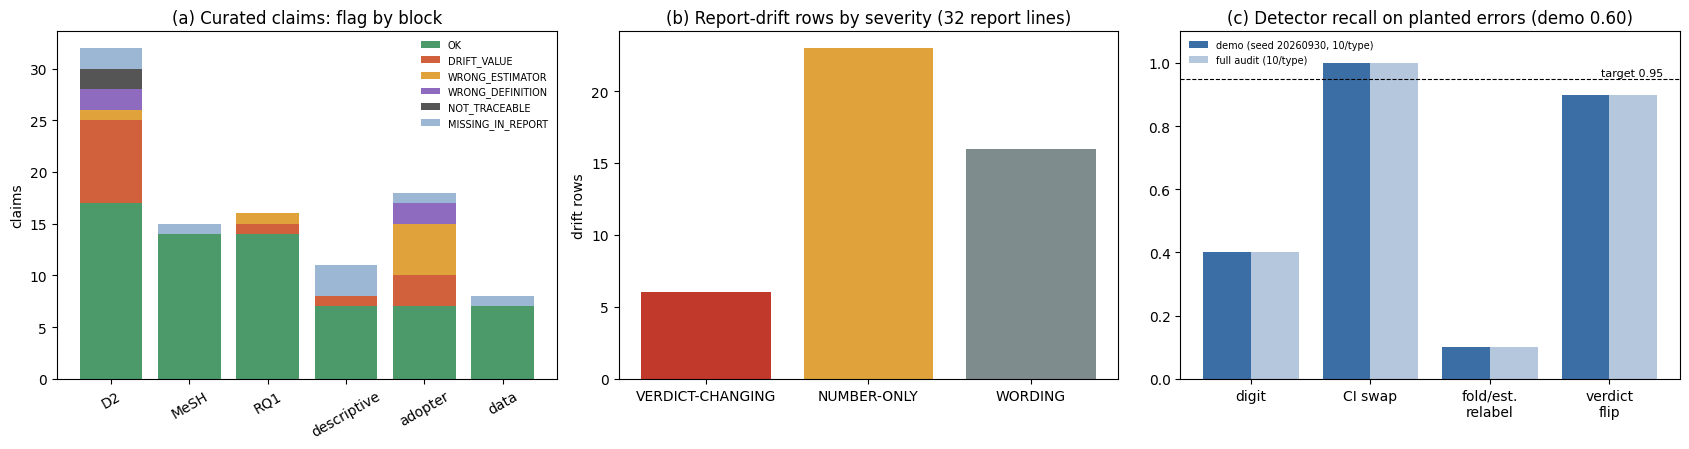

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))

# (a) claim flags by block
fl_order = ["OK", "DRIFT_VALUE", "WRONG_ESTIMATOR", "WRONG_DEFINITION", "NOT_TRACEABLE", "MISSING_IN_REPORT"]
colors = ["#4c9a6a", "#d1603d", "#e0a23a", "#8e6bbf", "#555555", "#9bb7d4"]
blocks_present = [b for b in BLOCK_ORDER if any(c["block"] == b for c in claims)]
bottom = np.zeros(len(blocks_present))
for f, col in zip(fl_order, colors):
    vals = np.array([sum(c["flag"] == f for c in claims if c["block"] == b) for b in blocks_present], dtype=float)
    axes[0].bar(blocks_present, vals, bottom=bottom, label=f, color=col)
    bottom += vals
axes[0].set_title("(a) Curated claims: flag by block")
axes[0].set_ylabel("claims")
axes[0].legend(fontsize=7, frameon=False)
axes[0].tick_params(axis="x", rotation=30)

# (b) drift rows by severity
sev_order = ["VERDICT-CHANGING", "NUMBER-ONLY", "WORDING"]
axes[1].bar(sev_order, [sev.get(s, 0) for s in sev_order], color=["#c0392b", "#e0a23a", "#7f8c8d"])
axes[1].set_title(f"(b) Report-drift rows by severity ({len(drift_lines)} report lines)")
axes[1].set_ylabel("drift rows")

# (c) seeded-injection recall by error type, demo vs full audit
types_ = ["digit_change", "ci_bound_swap", "estimator_fold_relabel", "verdict_flip"]
x = np.arange(len(types_))
axes[2].bar(x - 0.2, [inj["recall_by_type"].get(t, np.nan) for t in types_], 0.4, label=f"demo (seed {SEED_BLIND}, {N_PER_TYPE}/type)", color="#3b6ea5")
axes[2].bar(x + 0.2, [ref.get(f"M5_recall_{t}", np.nan) for t in types_], 0.4, label="full audit (10/type)", color="#b5c7dd")
axes[2].axhline(0.95, ls="--", c="k", lw=0.8)
axes[2].text(3.45, 0.96, "target 0.95", ha="right", fontsize=8)
axes[2].set_xticks(x, ["digit", "CI swap", "fold/est.\nrelabel", "verdict\nflip"])
axes[2].set_ylim(0, 1.1)
axes[2].set_title(f"(c) Detector recall on planted errors (demo {inj['recall']:.2f})")
axes[2].legend(fontsize=7, frameon=False, loc="upper left")
plt.tight_layout()
plt.show()

**How to read the results.**
- **Auto-scan traceability** covers the whole report. If the index slice is faithful, it matches the full audit, and nearly every report number has *some* matching source value.
- **Curated claims** are where the audit is reliable. The drift list gives, for each report line, the number or verdict that should be there and its source. The main examples:
  - RQ1 must be stated as `R1_DEAD` (held-out pooled-panel closure −0.391 [−0.855, 0.072], Holm 0.147);
  - the primary CT p is 0.85, not 0.48;
  - robustness is "20/26 including base and strata";
  - the adopter result is an odds ratio of 3.09, not "3.1× more likely".
- **Seeded injection** is the stated limitation. CI swaps and verdict flips are caught. Digit changes and fold relabels on uncurated prose lines are mostly missed, because a changed number usually still matches some other source value by chance.